# **Credit Risk Estimation**

# **Introduction**
Credit risk analysis is a crucial aspect of financial decision-making, helping institutions evaluate the **likelihood of a borrower defaulting** on a loan. Accurate credit risk prediction enables lenders to minimize losses while **maximizing profitable lending opportunities**. In this project, we aim to **predict credit risk** using a dataset containing relevant borrower information. By leveraging machine learning models, we will analyze patterns and relationships within the data to classify loan applications as either "good" or "bad" credit risks.

# **Objective**
The primary objective of this project is to develop an accurate classification model to predict credit risk. We will explore the dataset, preprocess the data, and evaluate the performance. The results will provide insights into the factors influencing credit risk and the effectiveness of each model.



# **Dataset Information**
The dataset used in this project includes the following features:


Here's a breakdown of each variable in your dataset:

1. **person_age** – The age of the loan applicant (borrower). Typically, younger borrowers may have a shorter credit history, while older borrowers may have more financial stability.

2. **person_income** – The applicant's total income. This is a crucial factor in determining the borrower's ability to repay the loan.

3. **person_home_ownership** – The type of home ownership the borrower has (e.g., "Rent", "Own", "Mortgage"). Homeownership status can influence creditworthiness.

4. **person_emp_length** – The number of years the borrower has been employed. Longer employment history generally indicates financial stability.

5. **loan_intent** – The purpose of the loan, such as "debt consolidation," "education," "medical," "home improvement," etc. Different loan intents may have varying levels of risk.

6. **loan_grade** – A credit grade assigned to the loan (e.g., A, B, C, D), indicating the risk level. A higher grade (A) means lower risk, while lower grades (D, E, etc.) indicate higher risk.

7. **loan_amnt** – The total amount of money borrowed by the applicant.

8. **loan_int_rate** – The interest rate charged on the loan. Higher risk borrowers may have higher interest rates.

9. **loan_status** – The current status of the loan (e.g., "Fully Paid", "Default", "Charged Off"). This indicates whether the borrower has repaid the loan successfully or not.

10. **loan_percent_income** – The percentage of the borrower's income that the loan amount represents. A higher percentage means a larger portion of income is required for loan repayment, which may indicate a higher risk of default.

11. **cb_person_default_on_file** – Indicates whether the borrower has previously defaulted on a loan (Yes/No). A past default can be a red flag for lenders.

12. **cb_person_cred_hist_length** – The length of the borrower's credit history in years. A longer credit history typically correlates with a stronger credit profile.

This dataset appears to be structured for credit risk analysis, helping lenders determine whether to approve a loan and at what terms. Would you like any further clarification?

The target variable, `loan_status`, is a categorical variable that we aim to predict, helping to classify applicants into good or bad credit risk categories.

 1 → Loan defaulted (High Risk)
 0 → Loan fully paid (Low Risk)

# **Machine Learning Models used for the task**


* Logistic Regression
* Random Forest
* Naive Bayes
* SVM
* XGBoost
* LightGBM
* CatBoost



In [ ]:
# import libraries
import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# data loading
from google.colab import drive
drive.mount('/content/drive')

file = "/content/drive/MyDrive/credit-risk/credit_risk_dataset.csv"
df = pd.read_csv(file)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
df.shape

(32581, 12)

In [ ]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [ ]:
df.columns

In [ ]:
df['loan_status'].unique()

array([1, 0])

In [ ]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


Method: Impute with median or use a model-based imputation (e.g., KNN imputation, regression model).
Reason: Employment length is a numerical feature. The number of missing values is quite high (895), so imputation with median is a common choice. Alternatively, you could use a machine learning model to predict missing values based on other features if the correlation is strong.

In [ ]:
# fillin missing values for person_emp_length
# df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [ ]:
# df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

df.head()
df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [ ]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


In [ ]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [ ]:
df.shape

(32581, 12)

In [ ]:
# 1 → Loan defaulted (High Risk)
# 0 → Loan fully paid (Low Risk)
# # Check unique values in loan_status (Target Variable)
print(df["loan_status"].value_counts())

loan_status
0    25473
1     7108
Name: count, dtype: int64


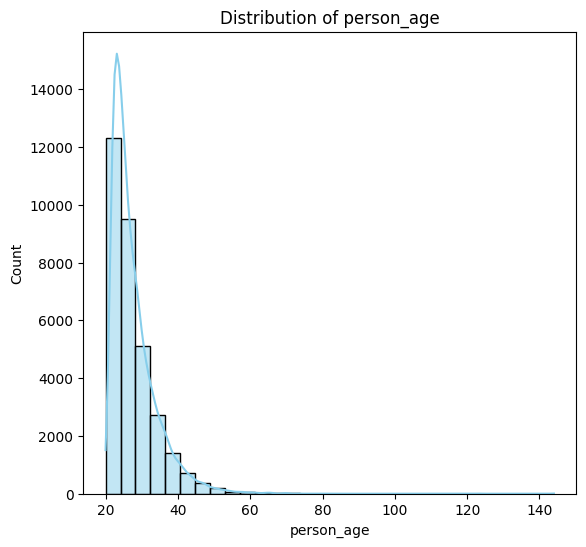

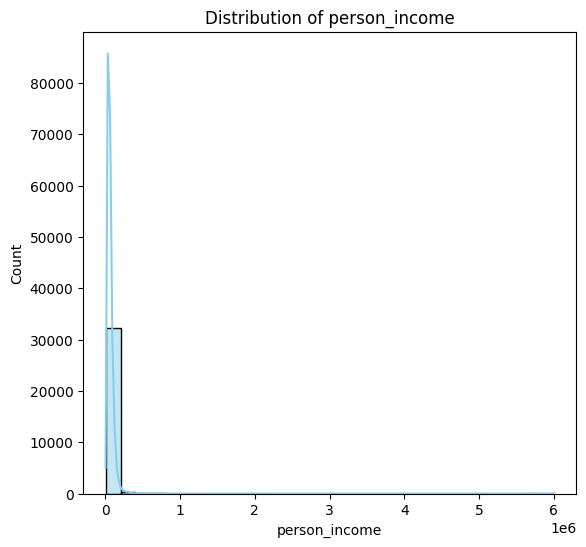

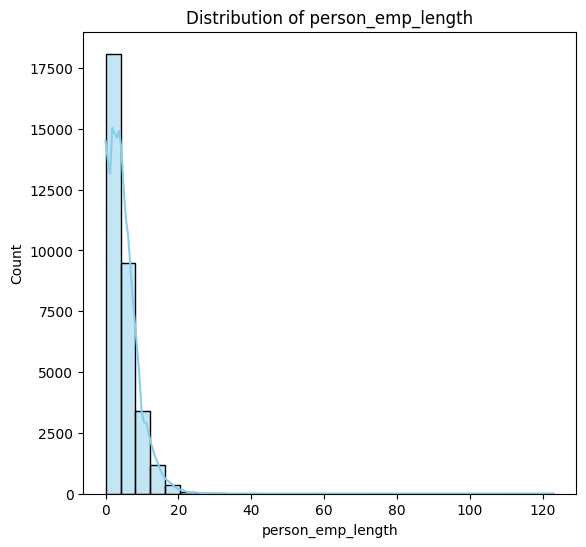

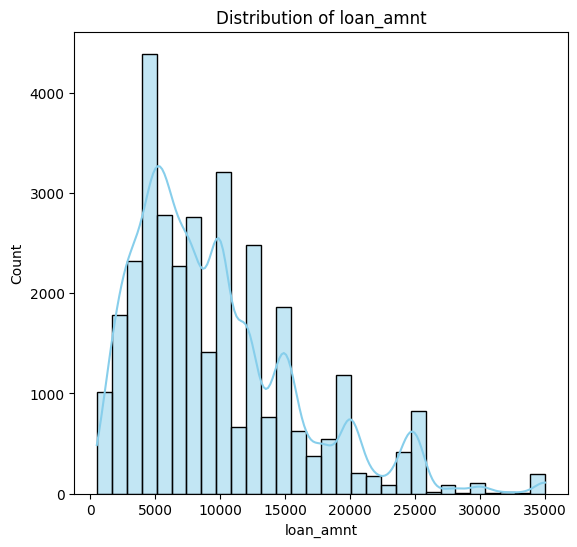

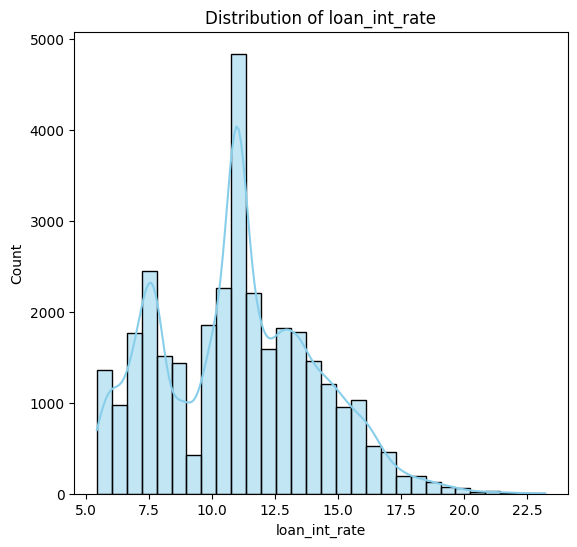

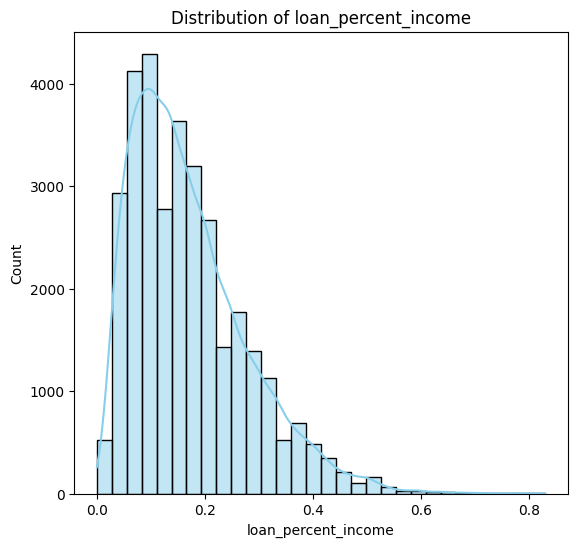

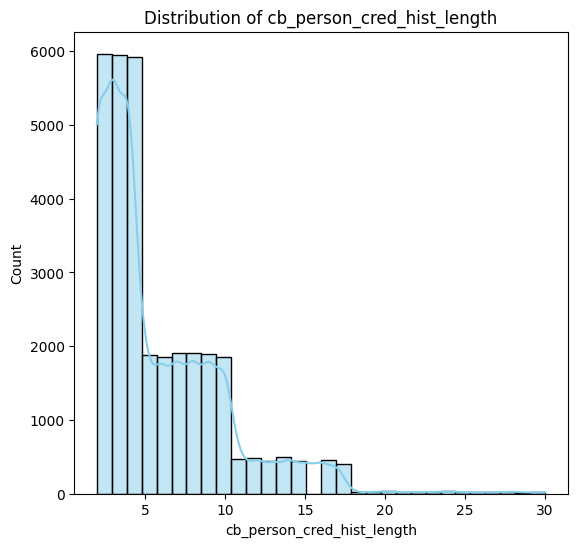

In [ ]:
num_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
            'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

# Histograms and Box Plots for Numerical Columns
for col in num_cols:
    plt.figure(figsize=(14, 6))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], bins=30, kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')

    plt.show()

<ipython-input-73-32a372a56754>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')


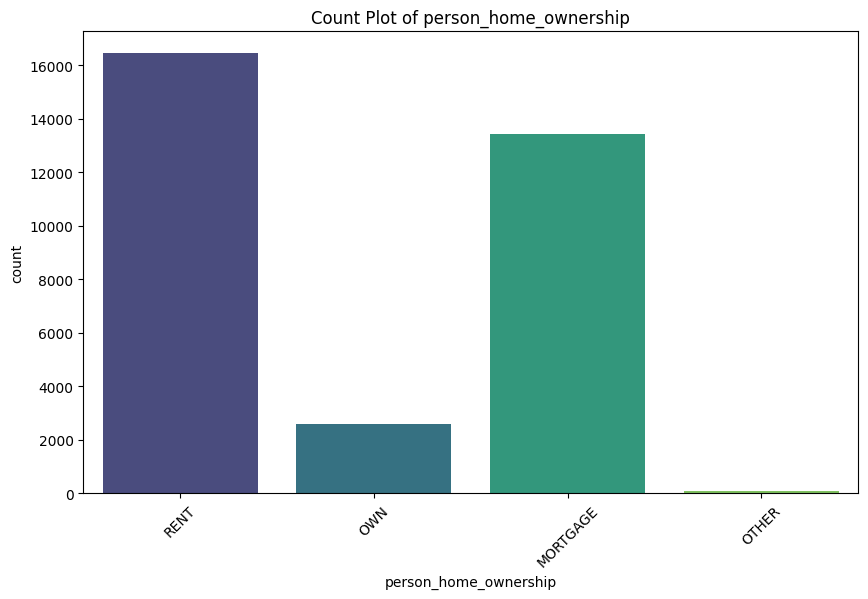

<ipython-input-73-32a372a56754>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')


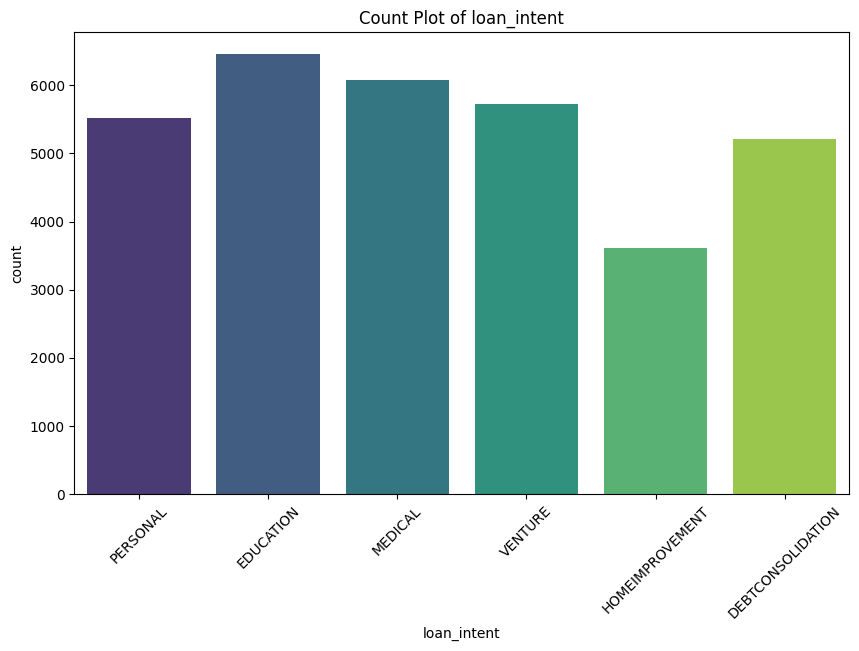

<ipython-input-73-32a372a56754>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')


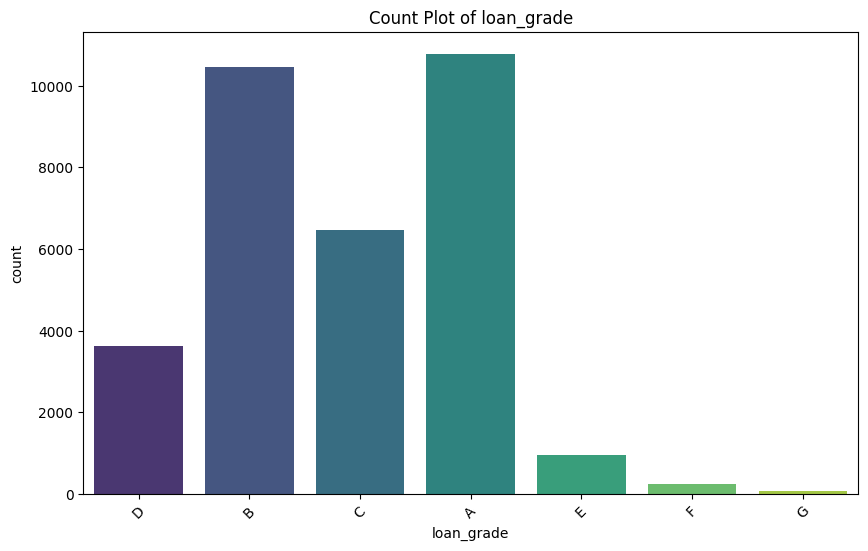

<ipython-input-73-32a372a56754>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')


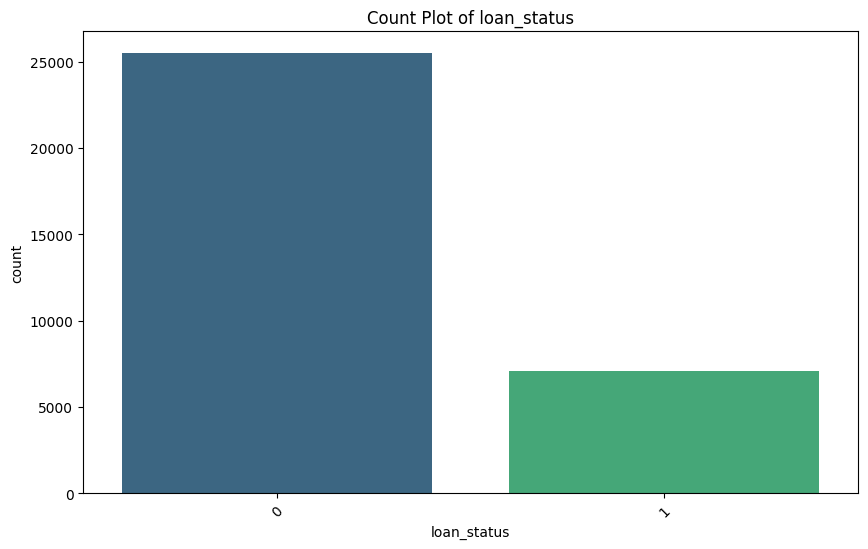

<ipython-input-73-32a372a56754>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')


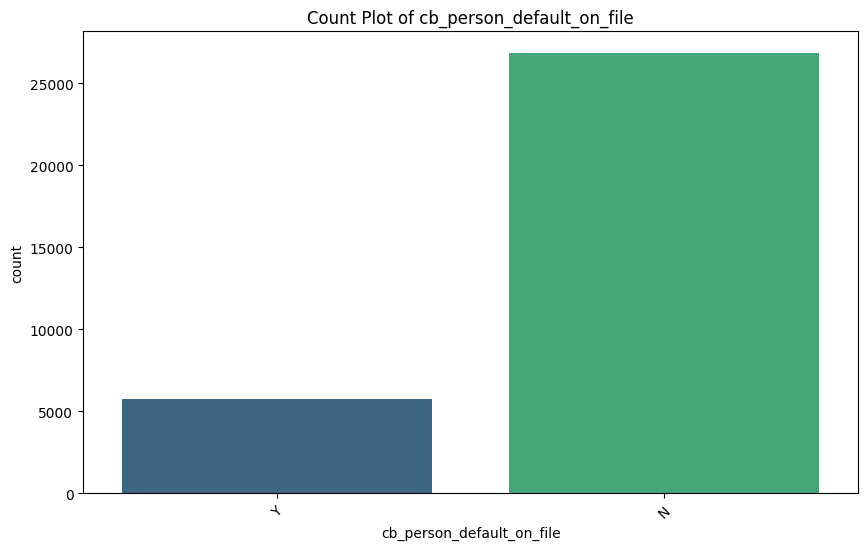

In [ ]:
# List of categorical columns
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade',
            'loan_status', 'cb_person_default_on_file']

# Count Plots for Categorical Columns
for col in cat_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=df[col], palette='viridis')
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
    plt.show()

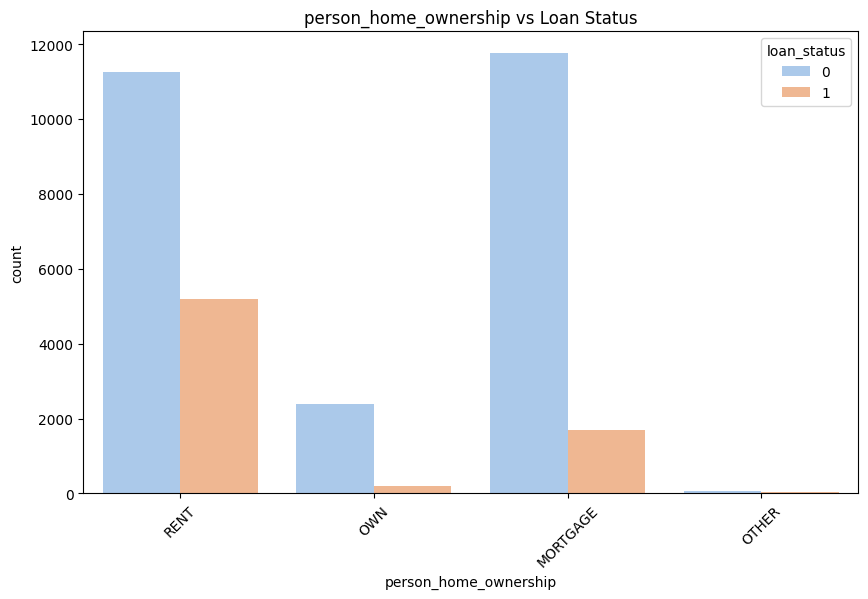

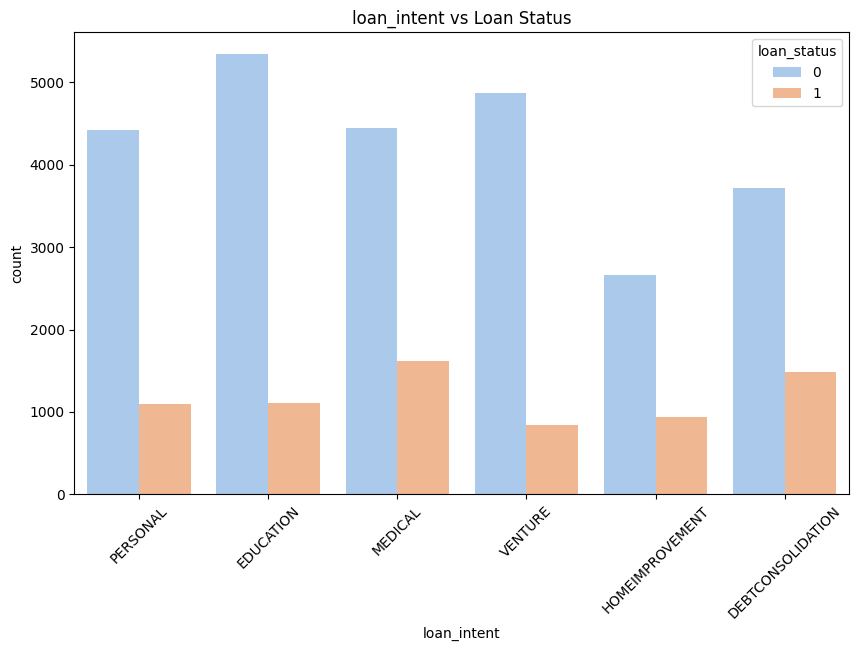

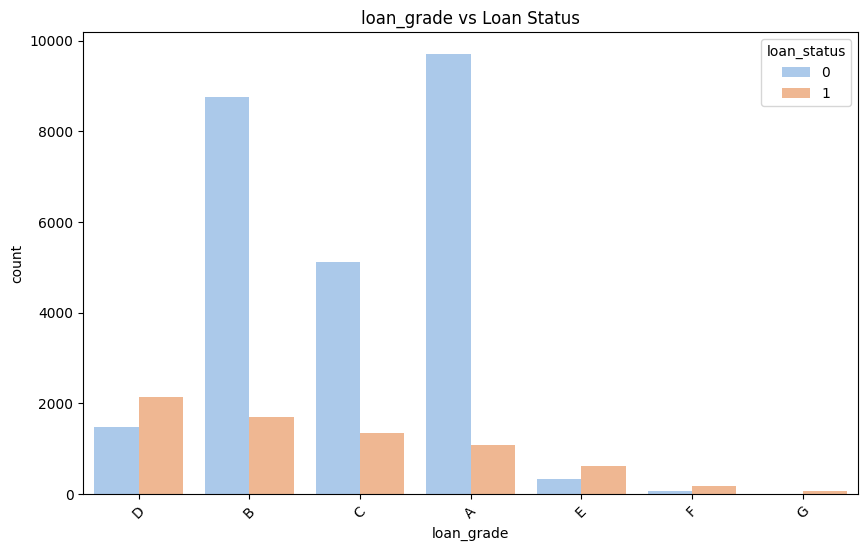

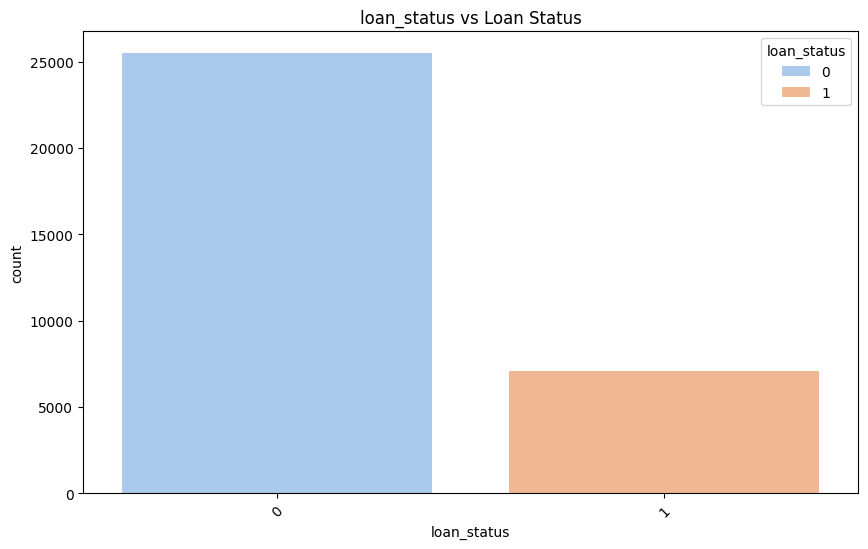

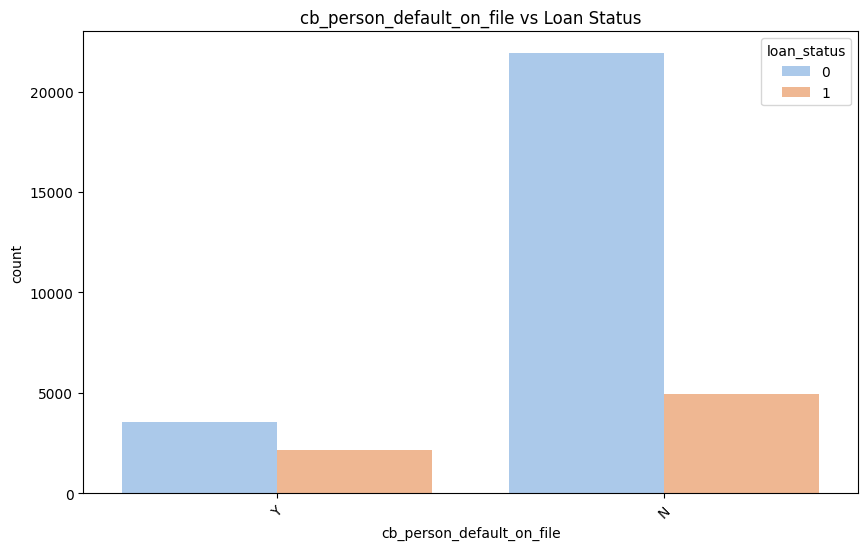

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=df[col], hue=df['loan_status'], palette='pastel')
    plt.title(f'{col} vs Loan Status')
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
# check unique values from person_home_ownership
person_home_ownership = df['person_home_ownership'].unique()
print(person_home_ownership)

['RENT' 'OWN' 'MORTGAGE' 'OTHER']


In [ ]:
# One-Hot Encoding for person_home_ownership
df_encoded = pd.get_dummies(df, columns=["person_home_ownership"])
df_encoded.tail()

,person_age,person_income,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT
32576,57,53000,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30,True,False,False,False
32577,54,120000,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19,True,False,False,False
32578,65,76000,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28,False,False,False,True
32579,56,150000,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26,True,False,False,False
32580,66,42000,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30,False,False,False,True


In [ ]:
# check unique values from loan_intent
loan_intent = df['loan_intent'].unique()
print(loan_intent)

['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']


In [ ]:
# One-Hot Encoding for gender
df_encoded = pd.get_dummies(df_encoded, columns=["loan_intent"])
df_encoded.tail()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
32576,57,53000,1.0,C,5800,13.16,0,0.11,N,30,True,False,False,False,False,False,False,False,True,False
32577,54,120000,4.0,A,17625,7.49,0,0.15,N,19,True,False,False,False,False,False,False,False,True,False
32578,65,76000,3.0,B,35000,10.99,1,0.46,N,28,False,False,False,True,False,False,True,False,False,False
32579,56,150000,5.0,B,15000,11.48,0,0.10,N,26,True,False,False,False,False,False,False,False,True,False
32580,66,42000,2.0,B,6475,9.99,0,0.15,N,30,False,False,False,True,False,False,False,True,False,False


In [ ]:
# check unique values from cb_person_default_on_file
cb_person_default_on_file = df['cb_person_default_on_file'].unique()
print(cb_person_default_on_file)

['Y' 'N']


In [ ]:
# LABEL ENCODING FOR cb_person_default_on_file
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df_encoded['cb_person_default_on_file'] = label_encoder.fit_transform(df_encoded['cb_person_default_on_file'])
# Display the transformed column
print(df_encoded['cb_person_default_on_file'].head())  # Show the first 5 rows of the transformed column
df_encoded.tail()

0    1
1    0
2    0
3    0
4    1
Name: cb_person_default_on_file, dtype: int64


,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
32576,57,53000,1.0,C,5800,13.16,0,0.11,0,30,True,False,False,False,False,False,False,False,True,False
32577,54,120000,4.0,A,17625,7.49,0,0.15,0,19,True,False,False,False,False,False,False,False,True,False
32578,65,76000,3.0,B,35000,10.99,1,0.46,0,28,False,False,False,True,False,False,True,False,False,False
32579,56,150000,5.0,B,15000,11.48,0,0.10,0,26,True,False,False,False,False,False,False,False,True,False
32580,66,42000,2.0,B,6475,9.99,0,0.15,0,30,False,False,False,True,False,False,False,True,False,False


In [ ]:
# check unique values from loan_grade
loan_grade = df['loan_grade'].unique()
print(loan_grade)

['D' 'B' 'C' 'A' 'E' 'F' 'G']


In [ ]:
# One-Hot Encoding for gender
df_encoded = pd.get_dummies(df_encoded, columns=["loan_grade"])
df_encoded.tail()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
32576,57,53000,1.0,5800,13.16,0,0.11,0,30,True,...,False,True,False,False,False,True,False,False,False,False
32577,54,120000,4.0,17625,7.49,0,0.15,0,19,True,...,False,True,False,True,False,False,False,False,False,False
32578,65,76000,3.0,35000,10.99,1,0.46,0,28,False,...,False,False,False,False,True,False,False,False,False,False
32579,56,150000,5.0,15000,11.48,0,0.10,0,26,True,...,False,True,False,False,True,False,False,False,False,False
32580,66,42000,2.0,6475,9.99,0,0.15,0,30,False,...,True,False,False,False,True,False,False,False,False,False


In [ ]:
df_encoded.shape

(32581, 26)

In [ ]:
df_encoded.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length',
       'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER',
       'person_home_ownership_OWN', 'person_home_ownership_RENT',
       'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_A',
       'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E',
       'loan_grade_F', 'loan_grade_G'],
      dtype='object')

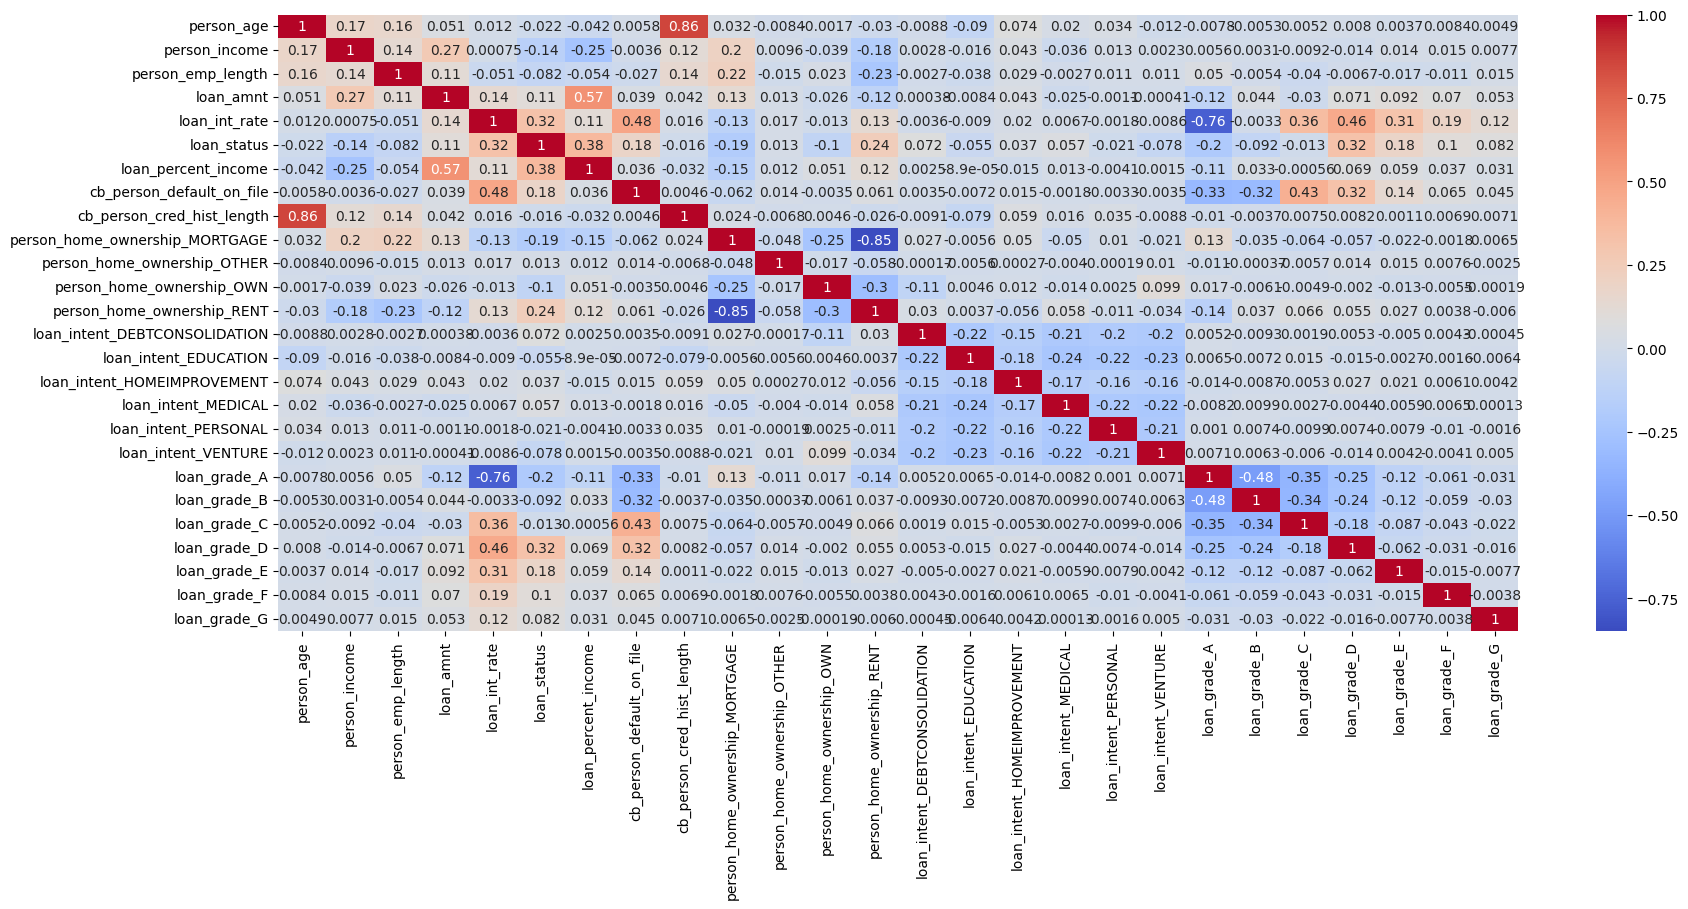

In [ ]:
# correlations
# correlation_matrix = df_encoded.corr()
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

# Correlation matrix
correlation_matrix = df_encoded.corr()

# Set figure size
plt.figure(figsize=(20, 8))  # Increase the width and height (adjust as needed)

# Create the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

# Show the plot
plt.show()


In [ ]:
# List of columns to drop
columns_to_drop = [
    "cb_person_cred_hist_length",  # Highly correlated with person_age
    "loan_int_rate",               # Highly correlated with loan_amnt
    # "person_home_ownership_OTHER", # Low impact
    # "loan_intent_VENTURE",         # Low impact
    "person_home_ownership_MORTGAGE"  # Strong correlation with RENT and OWN (keep only one)
]

# Drop the columns
df_encoded = df_encoded.drop(columns=columns_to_drop, axis=1)

# Display the updated DataFrame
df_encoded.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_status,loan_percent_income,cb_person_default_on_file,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
0,22,59000,123.0,35000,1,0.59,1,False,False,True,...,False,True,False,False,False,False,True,False,False,False
1,21,9600,5.0,1000,0,0.10,0,False,True,False,...,False,False,False,False,True,False,False,False,False,False
2,25,9600,1.0,5500,1,0.57,0,False,False,False,...,True,False,False,False,False,True,False,False,False,False
3,23,65500,4.0,35000,1,0.53,0,False,False,True,...,True,False,False,False,False,True,False,False,False,False
4,24,54400,8.0,35000,1,0.55,1,False,False,True,...,True,False,False,False,False,True,False,False,False,False


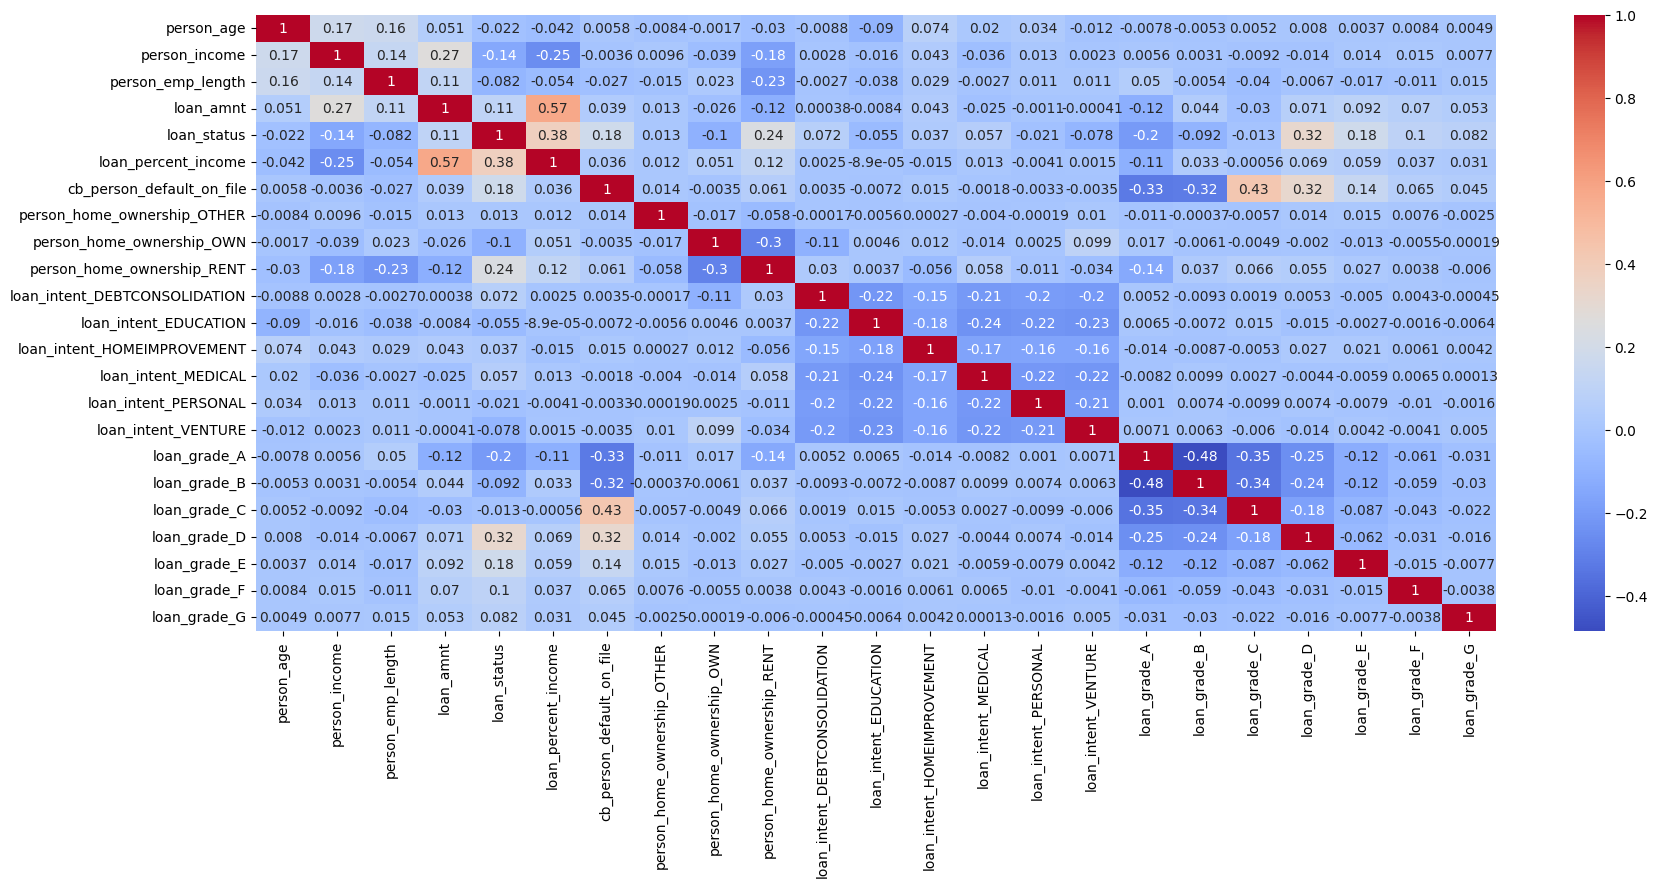

In [ ]:
# Correlation matrix
correlation_matrix = df_encoded.corr()

# Set figure size
plt.figure(figsize=(20, 8))  # Increase the width and height (adjust as needed)

# Create the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

# Show the plot
plt.show()

In [ ]:
df_encoded.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_status', 'loan_percent_income', 'cb_person_default_on_file',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'loan_grade_A', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D',
       'loan_grade_E', 'loan_grade_F', 'loan_grade_G'],
      dtype='object')

In [ ]:
# feature splitting

X = df_encoded.drop("loan_status", axis=1)
X.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_percent_income,cb_person_default_on_file,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
0,22,59000,123.0,35000,0.59,1,False,False,True,False,...,False,True,False,False,False,False,True,False,False,False
1,21,9600,5.0,1000,0.10,0,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
2,25,9600,1.0,5500,0.57,0,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
3,23,65500,4.0,35000,0.53,0,False,False,True,False,...,True,False,False,False,False,True,False,False,False,False
4,24,54400,8.0,35000,0.55,1,False,False,True,False,...,True,False,False,False,False,True,False,False,False,False


In [ ]:
X.columns
X.shape

(32581, 22)

In [ ]:
y = df_encoded['loan_status']
y.head()

,loan_status
0,1
1,0
2,1
3,1
4,1


In [ ]:
# scale data
from sklearn.preprocessing import StandardScaler
# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the data
X_scaled = scaler.fit_transform(X)

# Convert scaled data back to a DataFrame
X = pd.DataFrame(X_scaled, columns=[col for col in X.columns])
X.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_percent_income,cb_person_default_on_file,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
0,-0.903374,-0.114143,28.926614,4.019404,3.931411,2.161294,-0.057402,-0.293499,0.990500,-0.436388,...,-0.478548,2.213885,-0.461414,-0.703041,-0.687208,-0.497207,2.825842,-0.174614,-0.086325,-0.044364
1,-1.060904,-0.911147,0.056763,-1.358650,-0.657458,-0.462686,-0.057402,3.407161,-1.009591,-0.436388,...,-0.478548,-0.451695,-0.461414,-0.703041,1.455163,-0.497207,-0.353877,-0.174614,-0.086325,-0.044364
2,-0.430783,-0.911147,-0.921876,-0.646849,3.744110,-0.462686,-0.057402,-0.293499,-1.009591,-0.436388,...,2.089656,-0.451695,-0.461414,-0.703041,-0.687208,2.011234,-0.353877,-0.174614,-0.086325,-0.044364
3,-0.745843,-0.009274,-0.187897,4.019404,3.369508,-0.462686,-0.057402,-0.293499,0.990500,-0.436388,...,2.089656,-0.451695,-0.461414,-0.703041,-0.687208,2.011234,-0.353877,-0.174614,-0.086325,-0.044364
4,-0.588313,-0.188358,0.790742,4.019404,3.556809,2.161294,-0.057402,-0.293499,0.990500,-0.436388,...,2.089656,-0.451695,-0.461414,-0.703041,-0.687208,2.011234,-0.353877,-0.174614,-0.086325,-0.044364


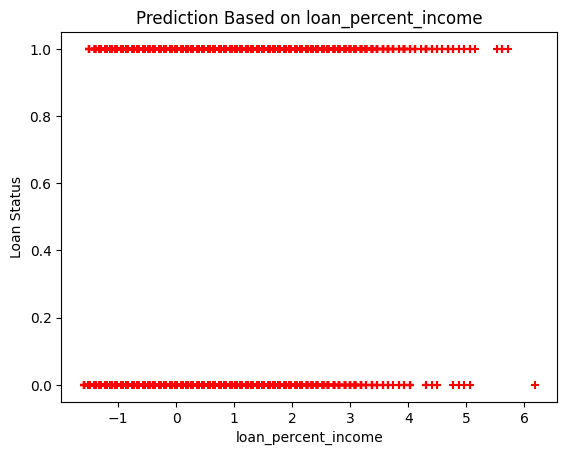

In [ ]:
# Scatter plot using 'age' from X and 'dropout' from y
plt.scatter(X['loan_percent_income'], y, marker='+', color='red')
plt.xlabel('loan_percent_income')  # Label for X-axis
plt.ylabel('Loan Status')  # Label for Y-axis
plt.title('Prediction Based on loan_percent_income')
plt.show()


In [ ]:
# Train and Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape

(26064, 22)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train,y_train)

RandomForestClassifier()

<h1 style="color:blue">CHECK OVERFITTING</h1>

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss

# Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Compute accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Compute log loss (need probability predictions)
y_train_proba = model.predict_proba(X_train)
y_test_proba = model.predict_proba(X_test)

train_loss = log_loss(y_train, y_train_proba)
test_loss = log_loss(y_test, y_test_proba)

# Print results
print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Train Loss (Log Loss): {train_loss:.4f}")
print(f"Test Loss (Log Loss): {test_loss:.4f}")


Train Accuracy: 0.9999
Test Accuracy: 0.9323
Train Loss (Log Loss): 0.0516
Test Loss (Log Loss): 0.2797


In [ ]:
# Measure accuracy
print(model.score(X_test,y_test))

0.9323308270676691


In [ ]:
# prediction
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
print(accuracy_score(y_pred,y_test))
print("-----" * 10)
print(confusion_matrix(y_pred,y_test))

0.9323308270676691
--------------------------------------------------
[[5022  391]
 [  50 1054]]


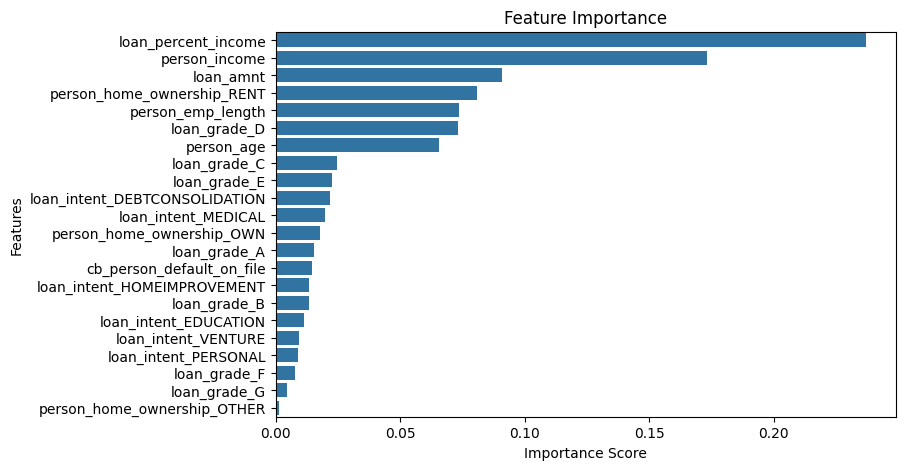

In [ ]:
# Extract feature importance
import seaborn as sns
feature_importance = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Plot feature importance
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importance, y=feature_importance.index)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

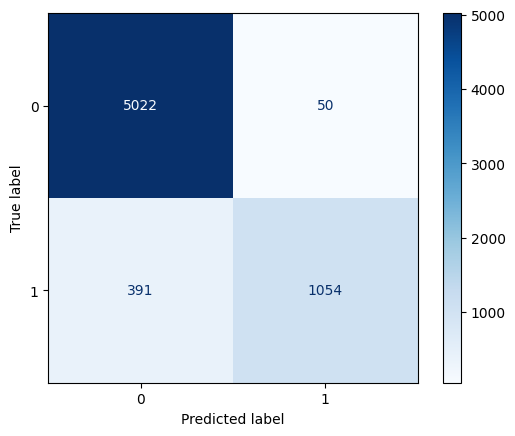

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()


In [ ]:
X_train.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_percent_income', 'cb_person_default_on_file',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'loan_grade_A', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D',
       'loan_grade_E', 'loan_grade_F', 'loan_grade_G'],
      dtype='object')

In [ ]:
print(f"First Independent Record: \n {X_train.iloc[0]}")  # If X_train is a Pandas DataFrame
print(f"First Dependant (loan status) Record: \n {y_train.iloc[0]}")  # If X_train is a Pandas DataFrame


First Independent Record: 
 person_age                       5.712903
person_income                   -0.323881
person_emp_length               -0.677217
loan_amnt                       -0.757573
loan_percent_income             -0.657458
cb_person_default_on_file        2.161294
person_home_ownership_OTHER     -0.057402
person_home_ownership_OWN       -0.293499
person_home_ownership_RENT       0.990500
loan_intent_DEBTCONSOLIDATION   -0.436388
loan_intent_EDUCATION           -0.496967
loan_intent_HOMEIMPROVEMENT     -0.352723
loan_intent_MEDICAL             -0.478548
loan_intent_PERSONAL             2.213885
loan_intent_VENTURE             -0.461414
loan_grade_A                    -0.703041
loan_grade_B                    -0.687208
loan_grade_C                     2.011234
loan_grade_D                    -0.353877
loan_grade_E                    -0.174614
loan_grade_F                    -0.086325
loan_grade_G                    -0.044364
Name: 32377, dtype: float64
First Dependant (loa

In [ ]:
# Predict the result for the input value (20 in this case)
# Define the input sample based on the feature list
input_sample = [[64, 46000, 2.0, 4800, 0.1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,0]]

# Predict using the trained model
prediction = model.predict(input_sample)

# Display the result
if prediction[0] == 0:
    print("Loan fully paid (Low Risk): 0")
else:
    print("Loan defaulted (High Risk): 1")

# 1 → Loan defaulted (High Risk)
# 0 → Loan fully paid (Low Risk)




Loan fully paid (Low Risk): 0


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
X.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_percent_income,cb_person_default_on_file,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
0,-0.903374,-0.114143,28.926614,4.019404,3.931411,2.161294,-0.057402,-0.293499,0.990500,-0.436388,...,-0.478548,2.213885,-0.461414,-0.703041,-0.687208,-0.497207,2.825842,-0.174614,-0.086325,-0.044364
1,-1.060904,-0.911147,0.056763,-1.358650,-0.657458,-0.462686,-0.057402,3.407161,-1.009591,-0.436388,...,-0.478548,-0.451695,-0.461414,-0.703041,1.455163,-0.497207,-0.353877,-0.174614,-0.086325,-0.044364
2,-0.430783,-0.911147,-0.921876,-0.646849,3.744110,-0.462686,-0.057402,-0.293499,-1.009591,-0.436388,...,2.089656,-0.451695,-0.461414,-0.703041,-0.687208,2.011234,-0.353877,-0.174614,-0.086325,-0.044364
3,-0.745843,-0.009274,-0.187897,4.019404,3.369508,-0.462686,-0.057402,-0.293499,0.990500,-0.436388,...,2.089656,-0.451695,-0.461414,-0.703041,-0.687208,2.011234,-0.353877,-0.174614,-0.086325,-0.044364
4,-0.588313,-0.188358,0.790742,4.019404,3.556809,2.161294,-0.057402,-0.293499,0.990500,-0.436388,...,2.089656,-0.451695,-0.461414,-0.703041,-0.687208,2.011234,-0.353877,-0.174614,-0.086325,-0.044364


<h1>END </h1>

<h1>REMOVE OVERFITTING and Retrain Different Models</h1>

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, accuracy_score
from sklearn.model_selection import GridSearchCV

# Define the model with regularization
model_Random_Forest = RandomForestClassifier(
    n_estimators=100,        # Number of trees (can reduce if needed)
    max_depth=10,            # Limit tree depth to prevent overfitting
    min_samples_split=10,    # Minimum samples to split a node
    min_samples_leaf=5,      # Minimum samples per leaf to prevent small splits
    max_features="sqrt",     # Use sqrt features per split (reduces overfitting)
    random_state=42,
    n_jobs=-1                # Use all CPU cores for faster training
)

# Train the model
model_Random_Forest.fit(X_train, y_train)

# Predict probabilities for loss calculation
train_probs = model_Random_Forest.predict_proba(X_train)
test_probs = model_Random_Forest.predict_proba(X_test)

# Compute Log Loss (Cross-Entropy Loss)
train_loss = log_loss(y_train, train_probs)
test_loss = log_loss(y_test, test_probs)

# Compute Accuracy
train_accuracy = accuracy_score(y_train, model_Random_Forest.predict(X_train))
test_accuracy = accuracy_score(y_test, model_Random_Forest.predict(X_test))

# Print results
print(f"Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")
print(f"Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")


Train Loss: 0.2328, Test Loss: 0.2493
Train Accuracy: 0.9337, Test Accuracy: 0.9290


In [ ]:
# Measure accuracy
print(model_Random_Forest.score(X_test,y_test))

0.9289550406628817


In [ ]:
# prediction
y_pred = model_Random_Forest.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
# Predict the result for the input value (20 in this case)
# Define the input sample based on the feature list
input_sample = [[64, 46000, 2.0, 4800, 0.1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,0]]

# Predict using the trained model
prediction = model_Random_Forest.predict(input_sample)

# Display the result
if prediction[0] == 0:
    print("Loan fully paid (Low Risk): 0")
else:
    print("Loan defaulted (High Risk): 1")

# 1 → Loan defaulted (High Risk)
# 0 → Loan fully paid (Low Risk)

Loan fully paid (Low Risk): 0


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import pickle

# Saving the model to a file
with open('credit_random_model.pkl', 'wb') as model_file:
    pickle.dump(model_Random_Forest, model_file)
print("Model saved successfully!")

Model saved successfully!


In [ ]:
X_train.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_percent_income', 'cb_person_default_on_file',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'loan_grade_A', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D',
       'loan_grade_E', 'loan_grade_F', 'loan_grade_G'],
      dtype='object')

In [ ]:
X_test.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_percent_income,cb_person_default_on_file,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
14668,-0.588313,-0.614287,0.301422,0.064952,1.777452,-0.462686,-0.057402,3.407161,-1.009591,-0.436388,...,-0.478548,-0.451695,-0.461414,-0.703041,1.455163,-0.497207,-0.353877,-0.174614,-0.086325,-0.044364
24614,-0.115722,-0.033475,-1.166536,0.064952,-0.095556,2.161294,-0.057402,-0.293499,0.990500,-0.436388,...,-0.478548,2.213885,-0.461414,-0.703041,-0.687208,2.011234,-0.353877,-0.174614,-0.086325,-0.044364
11096,-0.273252,0.095594,1.280061,1.014021,0.466346,-0.462686,-0.057402,-0.293499,-1.009591,-0.436388,...,-0.478548,-0.451695,-0.461414,-0.703041,-0.687208,-0.497207,2.825842,-0.174614,-0.086325,-0.044364
10424,-0.745843,-0.614352,0.546082,0.064952,1.777452,-0.462686,-0.057402,-0.293499,0.990500,2.291539,...,-0.478548,-0.451695,-0.461414,1.422391,-0.687208,-0.497207,-0.353877,-0.174614,-0.086325,-0.044364
26007,0.356869,-0.348082,-0.677217,0.539487,1.121899,-0.462686,-0.057402,-0.293499,0.990500,-0.436388,...,2.089656,-0.451695,-0.461414,-0.703041,-0.687208,-0.497207,-0.353877,5.726929,-0.086325,-0.044364


<p style="color:blue">Below is the Python code to train and evaluate multiple models (Logistic Regression, Random Forest, Naive Bayes, SVM, XGBoost, LightGBM, and CatBoost) in a loop. The code calculates and prints the accuracy and log loss for both the training and test sets for each model.</p>

<h1 style="color:blue">Different Model Training: Logistic Regression, Random Forest, Naive Bayes, SVM,XGBClassifier,
LGBMClassifier, CatBoostClassifier</h1>

In [ ]:
!pip install catboost
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import log_loss, accuracy_score, classification_report
import pandas as pd

# Define models
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42),  # Enable probability for log loss
    "XGBoost": XGBClassifier(random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(random_state=42, n_jobs=-1),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0)  # Disable training logs
}

# Train and evaluate models
results = {}
for name, model in models.items():
    print(f"\n Training {name}...")

    # Train the model
    model.fit(X_train, y_train)

    # Predict probabilities for log loss
    train_probs = model.predict_proba(X_train)
    test_probs = model.predict_proba(X_test)

    # Compute log loss
    train_loss = log_loss(y_train, train_probs)
    test_loss = log_loss(y_test, test_probs)

    # Compute accuracy
    train_accuracy = accuracy_score(y_train, model.predict(X_train))
    test_accuracy = accuracy_score(y_test, model.predict(X_test))

    # Compute classification report
    class_report = classification_report(y_test, model.predict(X_test), output_dict=True)

    # Store results
    results[name] = {
        "Train Loss": train_loss,
        "Test Loss": test_loss,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Precision": class_report["weighted avg"]["precision"],
        "Recall": class_report["weighted avg"]["recall"],
        "F1-Score": class_report["weighted avg"]["f1-score"]
    }

    # Print results
    print(f"  {name} Results:")
    print(f"  Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")
    print(f"  Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")
    print(f"  Precision: {results[name]['Precision']:.4f}, Recall: {results[name]['Recall']:.4f}, F1-Score: {results[name]['F1-Score']:.4f}")
    print("-" * 50)

# Display results in a table
results_df = pd.DataFrame(results).T
print("\n Summary of Results:")
print(results_df)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 7.8 MB/s eta 0:00:00

 Training Logistic Regression...
  Logistic Regression Results:
  Train Loss: 0.3381, Test Loss: 0.3464
  Train Accuracy: 0.8691, Test Accuracy: 0.8611
  Precision: 0.8537, Recall: 0.8611, F1-Score: 0.8522
--------------------------------------------------

 Training Random Forest...
  Random Forest Results:
  Train Loss: 0.2328, Test Loss: 0.2493
  Train Accuracy: 0.9337, Test Accuracy: 0.9290
  Precision: 0.9322, Recall: 0.9290, F1-Score: 0.9245
--------------------------------------------------

 Training Naive Bayes...
  Naive Bayes Results:
  Train Loss: 1.1585, Test Loss: 1.1830
  Train Accuracy: 0.8365, Test Accuracy: 0.8347
  Precision: 0.8221, Recall: 0.8347, F1-Score: 0.8207
--------------------------------------------------

 Training SVM...
  SVM Results:
  Train Loss: 0.2472, Test Loss: 0.2708
  Train Accuracy: 0.9176, Test Accuracy: 0.9089
  Precision: 0.9095, Recall: 0.9089, F1-Score: 0.9028
-

In [ ]:
results_df

,Train Loss,Test Loss,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.338075,0.346417,0.869091,0.861132,0.853650,0.861132,0.852166
Random Forest,0.232841,0.249342,0.933702,0.928955,0.932229,0.928955,0.924503
Naive Bayes,1.158496,1.183013,0.836479,0.834740,0.822112,0.834740,0.820674
SVM,0.247207,0.270782,0.917587,0.908854,0.909529,0.908854,0.902811
XGBoost,0.128446,0.186784,0.952425,0.932791,0.933615,0.932791,0.929658
LightGBM,0.157315,0.190022,0.942296,0.935553,0.938280,0.935553,0.931979
CatBoost,0.146201,0.187916,0.948051,0.936167,0.938547,0.936167,0.932765


<h1 style="color:blue">Prediction for each Model</h1>

In [ ]:
# prediction
# Make predictions with each model
y_preds = {}
for name, model in models.items():
    y_preds[name] = model.predict(X_test)

# Print the predictions for each model
for name, y_pred in y_preds.items():
    print(f"\nPredictions for {name}:")
    print(y_pred)



Predictions for Logistic Regression:
[0 0 0 ... 0 0 0]

Predictions for Random Forest:
[0 0 0 ... 0 0 0]

Predictions for Naive Bayes:
[0 0 0 ... 0 0 0]

Predictions for SVM:
[0 0 0 ... 0 0 0]

Predictions for XGBoost:
[0 0 0 ... 0 0 0]

Predictions for LightGBM:
[0 0 0 ... 0 0 0]

Predictions for CatBoost:
[0 0 0 ... 0 0 0]


<h1 style="color:blue">Confusion Matrix for each Model</h1>

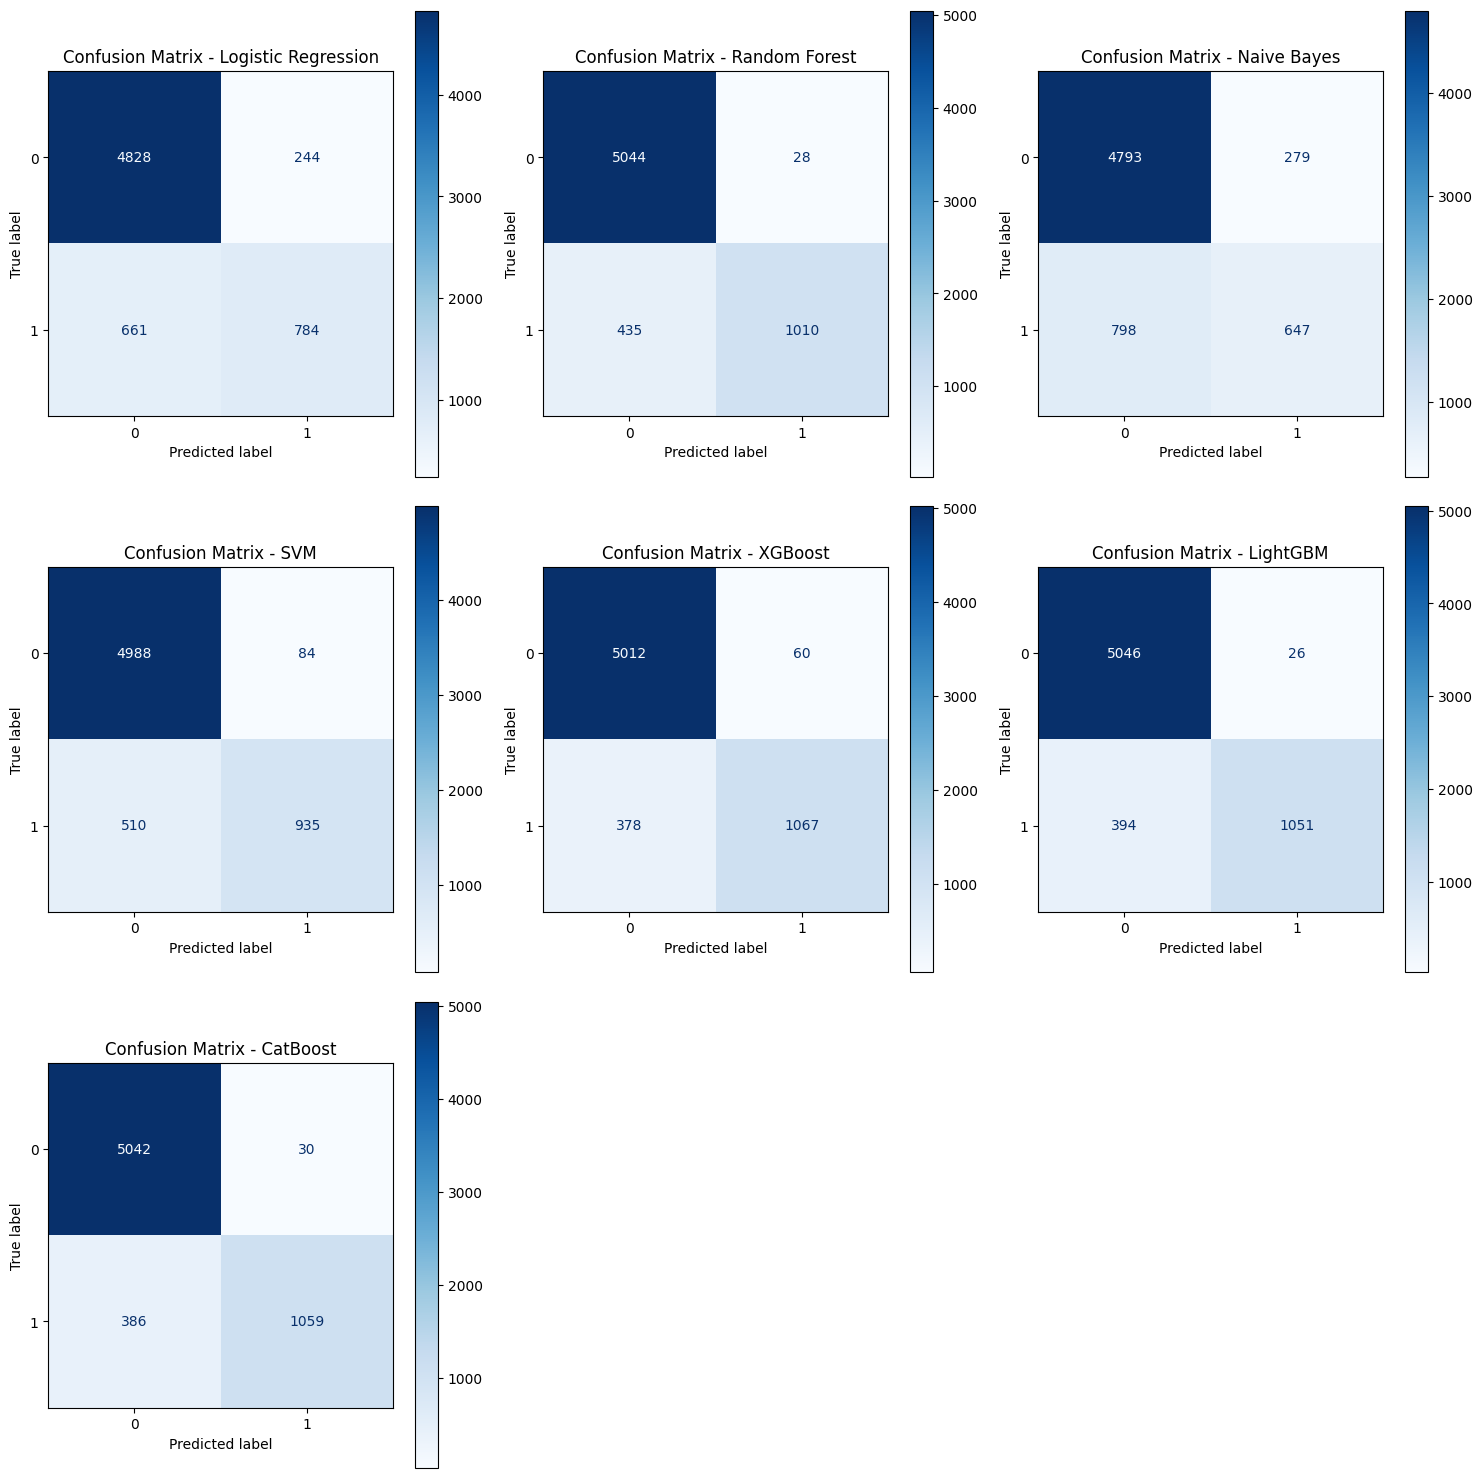

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Set up the figure and axes for plotting 3 models per row
n_rows = (len(models) + 2) // 3  # Calculate number of rows needed (round up if needed)
fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows * 5))

# Flatten axes array in case it's 2D for easier iteration
axes = axes.flatten()

# Iterate over each model and plot the confusion matrix
for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)  # Get predictions for each model

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot Confusion Matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap='Blues', ax=axes[i])
    axes[i].set_title(f"Confusion Matrix - {name}")

# Hide unused axes in the last row if necessary
for i in range(len(models), len(axes)):
    axes[i].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()


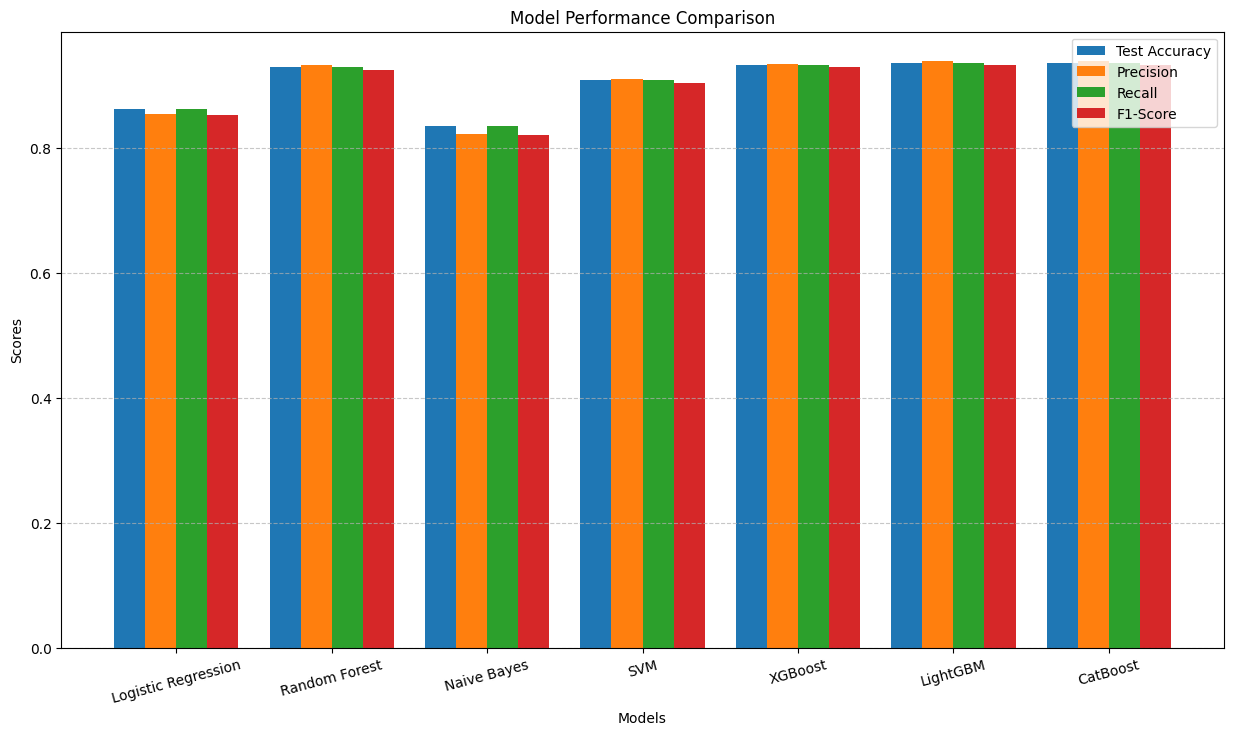

In [ ]:
bar_width = 0.2
plt.figure(figsize=(15, 8))
metrics = ['Test Accuracy', 'Precision', 'Recall', 'F1-Score']
index = np.arange(len(['Logistic Regression', 'Random Forest', 'Naive Bayes', 'SVM', 'XGBoost', 'LightGBM', 'CatBoost']))

# Create a bar for each metric
for i, metric in enumerate(metrics):
    plt.bar(index + i * bar_width, results_df[metric], bar_width, label=metric)

# Labels and title
plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Performance Comparison')
plt.xticks(index + 1.5 * bar_width, ['Logistic Regression', 'Random Forest', 'Naive Bayes', 'SVM', 'XGBoost', 'LightGBM', 'CatBoost'], rotation=15)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()

In [ ]:
import joblib

# Find the best model based on highest test accuracy
best_model_name = max(results, key=lambda x: results[x]["Test Accuracy"])
best_model = models[best_model_name]

# Save the best model
model_filename = f"/content/drive/MyDrive/credit-risk/best_model_{best_model_name.lower().replace(' ', '_')}.pkl"
joblib.dump(best_model, model_filename)

print(f"Best model ({best_model_name}) saved successfully as {model_filename}!")


Best model (CatBoost) saved successfully as /content/drive/MyDrive/credit-risk/best_model_catboost.pkl!


In [ ]:
model_names = ['Logistic Regression', 'Random Forest', 'Naive Bayes', 'SVM', 'XGBoost', 'LightGBM', 'CatBoost']
model_names.remove(best_model_name)

for model_name in model_names:
  model = models[model_name]
  model_filename = f"/content/drive/MyDrive/credit-risk/credit_risk_{model_name.lower().replace(' ', '_')}.pkl"
  joblib.dump(model, model_filename)
  print(f"Model ({model_name}) saved successfully as {model_filename}!")

Model (Logistic Regression) saved successfully as /content/drive/MyDrive/credit-risk/credit_risk_logistic_regression.pkl!
Model (Random Forest) saved successfully as /content/drive/MyDrive/credit-risk/credit_risk_random_forest.pkl!
Model (Naive Bayes) saved successfully as /content/drive/MyDrive/credit-risk/credit_risk_naive_bayes.pkl!
Model (SVM) saved successfully as /content/drive/MyDrive/credit-risk/credit_risk_svm.pkl!
Model (XGBoost) saved successfully as /content/drive/MyDrive/credit-risk/credit_risk_xgboost.pkl!
Model (LightGBM) saved successfully as /content/drive/MyDrive/credit-risk/credit_risk_lightgbm.pkl!
